ＡIプログラミング2 5,6回目<br>

# 1.pytorchの勉強

(1)Tensorへの変換

In [1]:
#pytorchの読み込み
import torch

L=[1,2,3]
a = torch.tensor(L)

print("aの型:",type(a))


aの型: <class 'torch.Tensor'>


In [2]:
#numpyの場合
#numpyの読み込み
import numpy as np
L=[1,2,3]

b=np.array(L)
print("bの型", type(b),)

bの型 <class 'numpy.ndarray'>


(2)範囲内のデータを生成

In [3]:
print("-3から3までのn個生成")

g = torch.linspace(-3, +3, 5)
print(g)

#numpyのとき
gn=np.arange(-3,3,0.5)
print(gn)

-3から3までのn個生成
tensor([-3.0000, -1.5000,  0.0000,  1.5000,  3.0000])
[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2.   2.5]


(3)numpyからTensor

In [5]:
print("tesor to numpy")

a = torch.tensor([[1,2], [3,4.0]])
print("a:",a)

b = a.numpy()
print("b:",b)



tesor to numpy
a: tensor([[1., 2.],
        [3., 4.]])
b: [[1. 2.]
 [3. 4.]]


(4)Tensor からNumpy

In [7]:
b=np.array([[1,2,3], [3,2,1]])
print("b:",b)
c = torch.from_numpy(b)

print("c:",c)

b: [[1 2 3]
 [3 2 1]]
c: tensor([[1, 2, 3],
        [3, 2, 1]])


(5)Tensorの一部にアクセス

In [9]:
a=torch.tensor([[1,2,3], [4,7,1]])

#特定の場所1つの指定
print("1:", a[0,2])

#範囲を指定
print("2:", a[1:2, :1])
print("3:", a[1:2, 1:])

#指定した値より大きい要素のみ
print("4:", a[a>4])

#要素の変更
a[:, 1]=9
print("5:", a)

#指定した数値より小さい要素のみ変更
a[a<3]=0
print("6:",a)


1: tensor(3)
2: tensor([[4]])
3: tensor([[7, 1]])
4: tensor([7])
5: tensor([[1, 9, 3],
        [4, 9, 1]])
6: tensor([[0, 9, 3],
        [4, 9, 0]])


# 2.Tensorの演算

(1)ベクトルと行列関連

In [12]:
#ベクトルを作る
a=torch.tensor([1,2,3])
b=torch.tensor([9,7,6])

#ベクトルの計算

print("1:",c)

#ベクトル同士の加算
d = a+b
print("2:",d)

#ベクトル同士の*
e = a*b
print("3:",e)


#行列を作る
f=torch.tensor([[6,5,4],
                [3,7,9]])

#行列同士の足し算
g = 3*f+f
print("4:",g)

#行列＋ベクトル（ブロードキャスト)
h = f+a
print("5:",h)


1: tensor([[1, 2, 3],
        [3, 2, 1]])
2: tensor([10,  9,  9])
3: tensor([ 9, 14, 18])
4: tensor([[24, 20, 16],
        [12, 28, 36]])
5: tensor([[ 7,  7,  7],
        [ 4,  9, 12]])


(2)形状変換

In [13]:
a=torch.tensor([-1,1,2,3,4,5,6,7])
print("0:",a)

#2次元の2x4に変換
b = a.view(2, 4)
print("1:",b)

#次元の要素を自動計算して形状変換
c = a.view(2, -1)
print("2:",c)

#1次元に変換
d = a.view(-1)
print("3:",d)


0: tensor([-1,  1,  2,  3,  4,  5,  6,  7])
1: tensor([[-1,  1,  2,  3],
        [ 4,  5,  6,  7]])
2: tensor([[-1,  1,  2,  3],
        [ 4,  5,  6,  7]])
3: tensor([-1,  1,  2,  3,  4,  5,  6,  7])


(3)形状の確認

In [14]:
a=torch.arange(0,8)
print ("0:", a, a.shape)

b=a.view(1,2,1,4)
print("1:",b,b.shape)

c=torch.tensor([[1,2,3],[5,7,9]])
print("2:",c,c.shape)

0: tensor([0, 1, 2, 3, 4, 5, 6, 7]) torch.Size([8])
1: tensor([[[[0, 1, 2, 3]],

         [[4, 5, 6, 7]]]]) torch.Size([1, 2, 1, 4])
2: tensor([[1, 2, 3],
        [5, 7, 9]]) torch.Size([2, 3])


# 3.統計量の計算

(1)平均

In [16]:
#torch.mean平均を求める関数(データタイプに注意)
#a=torch.tensor([2,9,7,-3,1,2])   #エラーになる
a=torch.tensor([2,9,7,-3,1,2.0])
m = torch.mean(a)
print("1:", m.item())

#平均値を求めるメソッド
m2 = a.mean()

print("2:", m2.item())
print("3:", m2)


1: 3.0
2: 3.0
3: tensor(3.)


(2)合計、最大値、最小値

In [17]:
#合計
a=torch.tensor([2,9,7,-3,1,2.0])
s = torch.sum(a)
print("1:", s.item())


#最大最小値
max = torch.max(a)
print("2:",max.item())

print("3:", torch.min(a).item())


1: 18.0
2: 9.0
3: -3.0


# 4.Tensor同士の計算(行列とベクトル)追加

(1)行列とベクトル演算

In [18]:
L=torch.tensor([1,2,3,4,5,6,7,8, 9.0])
a = L.view(3,3)

#演算の種類, +,-,*,/(商), //(商の整数部), %(余り)

b=torch.tensor([1,2,3])

#+
c = a+b
print("1:",c)

d = a-b
print("2:",d)

e = a*b
print("3:",e)

f = a/b
print("4:",f)

g = a//b
print("5:",g)

h = a%b
print("6:", h)


1: tensor([[ 2.,  4.,  6.],
        [ 5.,  7.,  9.],
        [ 8., 10., 12.]])
2: tensor([[0., 0., 0.],
        [3., 3., 3.],
        [6., 6., 6.]])
3: tensor([[ 1.,  4.,  9.],
        [ 4., 10., 18.],
        [ 7., 16., 27.]])
4: tensor([[1.0000, 1.0000, 1.0000],
        [4.0000, 2.5000, 2.0000],
        [7.0000, 4.0000, 3.0000]])
5: tensor([[1., 1., 1.],
        [4., 2., 2.],
        [7., 4., 3.]])
6: tensor([[0., 0., 0.],
        [0., 1., 0.],
        [0., 0., 0.]])


(2)Tensorの演算(行列同士)

In [19]:
L1=torch.tensor([1,2,3,4,5,6,7,8, 9.0])
#3x3の行列に変換
a=L.view(3,3)
L2=torch.arange(-9,0,1)
#3x3の行列に変換
b=L2.view(3,3)

print("a:\n",a)
print("b:\n",b)

#演算の種類, +,-,*,/(商), //(商の整数部), %(余り)


#和+
c = a+b
print("1:",c)

#差-
d = a-b
print("2:",d)

#積*  matmulとは違う
e = a*b
print("3:",e)

#商 / 小数点有
f = a/b
print("4:",f)

#商整数 //
g = a//b
print("5:",g)

#あまり %
h = a%b
print("6:", h)


a:
 tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])
b:
 tensor([[-9, -8, -7],
        [-6, -5, -4],
        [-3, -2, -1]])
1: tensor([[-8., -6., -4.],
        [-2.,  0.,  2.],
        [ 4.,  6.,  8.]])
2: tensor([[10., 10., 10.],
        [10., 10., 10.],
        [10., 10., 10.]])
3: tensor([[ -9., -16., -21.],
        [-24., -25., -24.],
        [-21., -16.,  -9.]])
4: tensor([[-0.1111, -0.2500, -0.4286],
        [-0.6667, -1.0000, -1.5000],
        [-2.3333, -4.0000, -9.0000]])
5: tensor([[-1., -1., -1.],
        [-1., -1., -2.],
        [-3., -4., -9.]])
6: tensor([[-8., -6., -4.],
        [-2.,  0., -2.],
        [-2.,  0.,  0.]])


# 5.活性化関数pytorch版

(1)シグモイド関数

<function matplotlib.pyplot.show(close=None, block=None)>

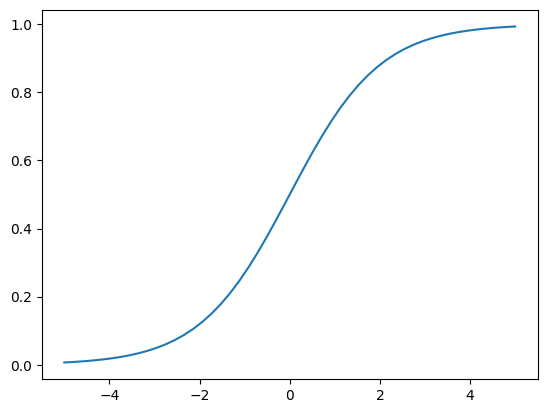

In [20]:
import torch
from torch import nn
import matplotlib.pylab as plt

#シグモイド関数を関数mで使えるようにします。
#関数の役割のコピーみなたいなもの
m = nn.Sigmoid()

#-5から5までを50分割
x=torch.linspace(-5,5,50)
#シグモイド関数を通す
y=m(x)

plt.plot(x,y)
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

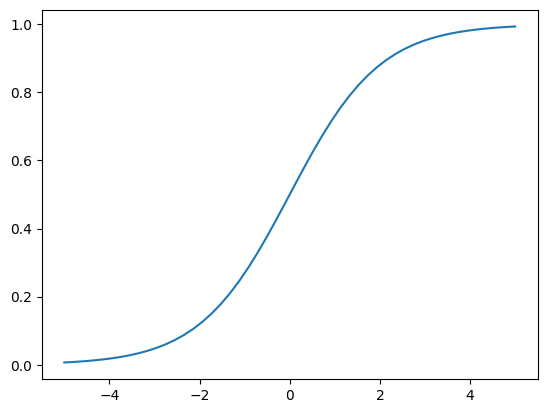

In [21]:
#torchのsigmoid関数を使わなくても作れます。
#でも、無理する必要はないです。
import torch
#from torch import nn
import matplotlib.pylab as plt

x=torch.linspace(-5,5,50)

y=1/(1+torch.exp(-x))
plt.plot(x,y)
plt.show

(2)tanhの場合

<function matplotlib.pyplot.show(close=None, block=None)>

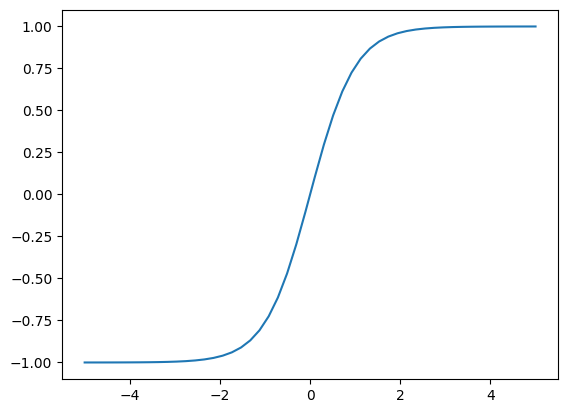

In [22]:
import torch
from torch import nn
import matplotlib.pylab as plt

#Tanhを使う
m = nn.Tanh()

x=torch.linspace(-5,5,50)
#y=torch.tanh(x) #これでも動きますよ。
y=m(x)

plt.plot(x,y)
plt.show



(3)ReLU関数

<function matplotlib.pyplot.show(close=None, block=None)>

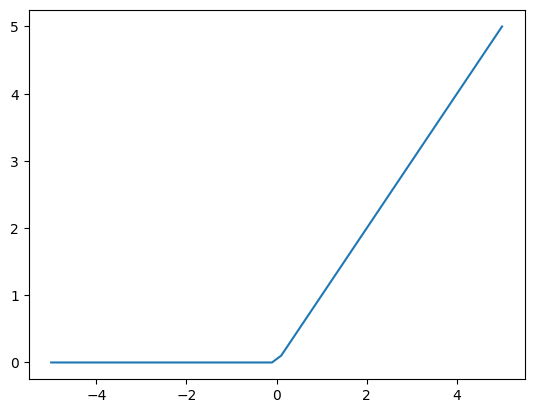

In [24]:
import torch
from torch import nn
import matplotlib.pylab as plt

#ReLU関数を使う準備
m = nn.ReLU()

x=torch.linspace(-5,5,50)
y=m(x)

plt.plot(x,y)
plt.show



#課題2
GeLU関数をグラフ化せよ。<br>
$GeLU(x)=0.5x(1+\tanh(\sqrt(\frac{2}{\pi})(x+0.0447715x^3))$


<function matplotlib.pyplot.show(close=None, block=None)>

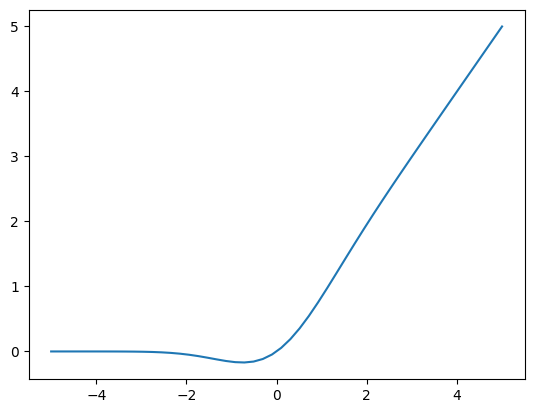

In [27]:
import torch
from torch import nn
import matplotlib.pylab as plt

#GELU関数を使う準備 調べてみよう
m = nn.GELU()

x=torch.linspace(-5,5,50)
y=m(x)

plt.plot(x,y)
plt.show

